#Mini-Project

##Import Libraries

In [ ]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

##Upload Files

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving diamonds.csv to diamonds.csv


##REGRESSION (DIAMONDS DATASET)

##Load Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/AML_Lab_B19/Mini Project/diamonds.csv")
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


##Data Cleaning

In [ ]:
# Drop unnecessary column
df.drop("Unnamed: 0", axis=1, inplace=True)

# Convert categorical → numerical
le = LabelEncoder()
df['cut'] = le.fit_transform(df['cut'])
df['color'] = le.fit_transform(df['color'])
df['clarity'] = le.fit_transform(df['clarity'])

df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,1,3,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,1,2,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,1,4,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,5,5,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,6,3,63.3,58.0,335,4.34,4.35,2.75


##Define Features & Target

In [ ]:
X = df.drop("price", axis=1)
y = df["price"]

##Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##Scaling

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))

Linear Regression
MSE: 1825912.9915253469
R2: 0.8851397433679632


##Ridge (L2)

In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("Ridge Regression")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R2:", r2_score(y_test, y_pred_ridge))

Ridge Regression
MSE: 1825909.0212341927
R2: 0.8851399931217374


##Lasso (L1)

In [ ]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("Lasso Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R2:", r2_score(y_test, y_pred_lasso))

Lasso Regression
MSE: 1825927.7513892818
R2: 0.8851388148890229


##Comparison Table

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso"],
    "MSE": [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso)
    ],
    "R2 Score": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ]
})

results

,Model,MSE,R2 Score
0,Linear,1.825913e+06,0.885140
1,Ridge,1.825909e+06,0.885140
2,Lasso,1.825928e+06,0.885139


--------------------

##CLASSIFICATION (GLASS DATASET)

##Load Dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/AML_Lab_B19/Mini Project/glass (1).csv")
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


##Features & Target

In [ ]:
X = df.drop("Type", axis=1)
y = df["Type"]

##Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##Scaling

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##Logistic Regression (L2)

In [ ]:
log_l2 = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000)
log_l2.fit(X_train, y_train)

y_pred_l2 = log_l2.predict(X_test)

print("L2 Regularization")
print(classification_report(y_test, y_pred_l2))

L2 Regularization
              precision    recall  f1-score   support

           1       0.56      0.82      0.67        11
           2       0.50      0.57      0.53        14
           3       0.00      0.00      0.00         3
           5       1.00      0.25      0.40         4
           6       0.00      0.00      0.00         3
           7       0.80      1.00      0.89         8

    accuracy                           0.60        43
   macro avg       0.48      0.44      0.41        43
weighted avg       0.55      0.60      0.55        43



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##Logistic Regression (L1)

In [ ]:
log_l1 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
log_l1.fit(X_train, y_train)

y_pred_l1 = log_l1.predict(X_test)

print("L1 Regularization")
print(classification_report(y_test, y_pred_l1))

L1 Regularization
              precision    recall  f1-score   support

           1       0.56      0.82      0.67        11
           2       0.47      0.57      0.52        14
           3       0.00      0.00      0.00         3
           5       1.00      0.25      0.40         4
           6       0.00      0.00      0.00         3
           7       0.89      1.00      0.94         8

    accuracy                           0.60        43
   macro avg       0.49      0.44      0.42        43
weighted avg       0.56      0.60      0.55        43



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##Confusion Matrix

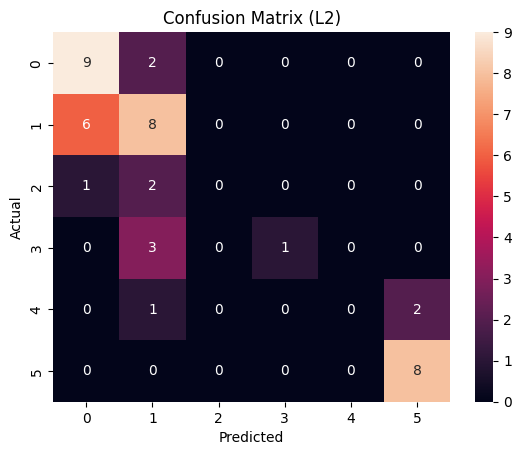

In [ ]:
cm = confusion_matrix(y_test, y_pred_l2)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix (L2)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##Accuracy Comparison

In [ ]:
print("Accuracy L1:", accuracy_score(y_test, y_pred_l1))
print("Accuracy L2:", accuracy_score(y_test, y_pred_l2))

Accuracy L1: 0.6046511627906976
Accuracy L2: 0.6046511627906976


##Import Required Libraries

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

##Binarize Target

In [ ]:
# Convert multiclass → binary format
classes = np.unique(y)
y_bin = label_binarize(y, classes=classes)

n_classes = y_bin.shape[1]

##Train Model (L2 with OvR)

In [ ]:
model = OneVsRestClassifier(LogisticRegression(solver='liblinear'))
model.fit(X_train, label_binarize(y_train, classes=classes))

y_score = model.predict_proba(X_test)

##Compute ROC & AUC

In [ ]:
fpr = dict()
tpr = dict()
roc_auc = dict()

y_test_bin = label_binarize(y_test, classes=classes)

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

##Plot ROC Curve

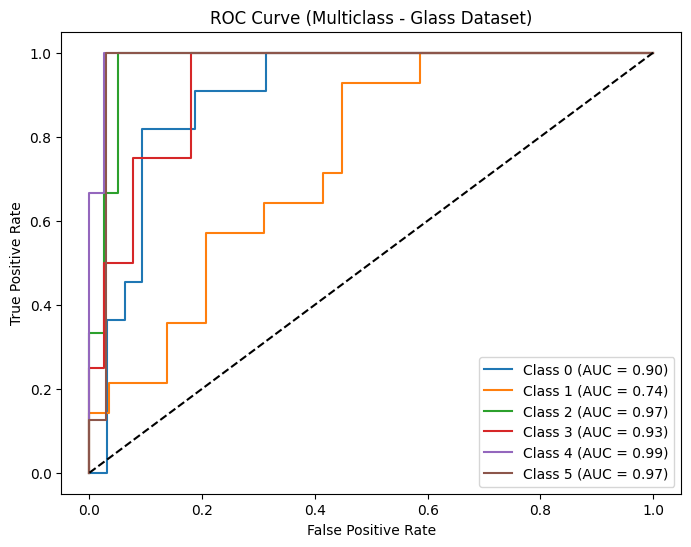

In [ ]:
plt.figure(figsize=(8,6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multiclass - Glass Dataset)")
plt.legend()
plt.show()

##Compare L1 vs L2 ROC

####L1 ROC

In [ ]:
model_l1 = OneVsRestClassifier(LogisticRegression(penalty='l1', solver='liblinear'))
model_l1.fit(X_train, label_binarize(y_train, classes=classes))

y_score_l1 = model_l1.predict_proba(X_test)

##Plot L1 vs L2

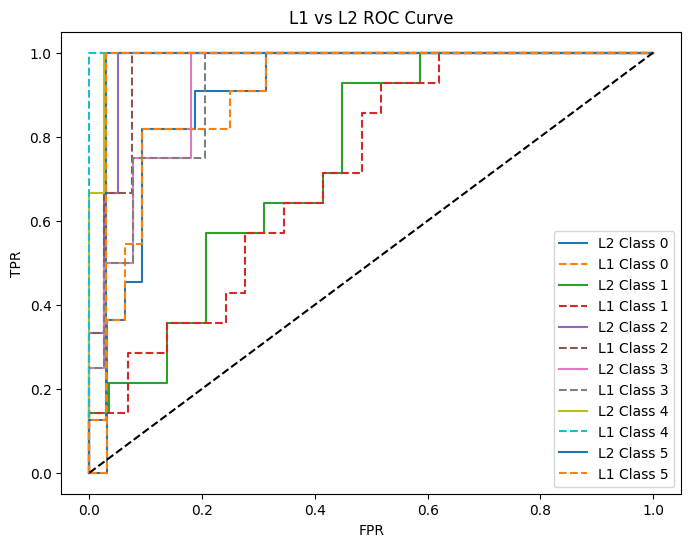

In [ ]:
plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr_l2, tpr_l2, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    fpr_l1, tpr_l1, _ = roc_curve(y_test_bin[:, i], y_score_l1[:, i])

    plt.plot(fpr_l2, tpr_l2, linestyle='-', label=f"L2 Class {i}")
    plt.plot(fpr_l1, tpr_l1, linestyle='--', label=f"L1 Class {i}")

plt.plot([0,1], [0,1], 'k--')
plt.title("L1 vs L2 ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

##Compute Macro-Average ROC

In [ ]:
# Aggregate all FPR points
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Interpolate all ROC curves at these points
mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Average it
mean_tpr /= n_classes

# Compute AUC
macro_auc = auc(all_fpr, mean_tpr)

##Plot Macro-Average ROC

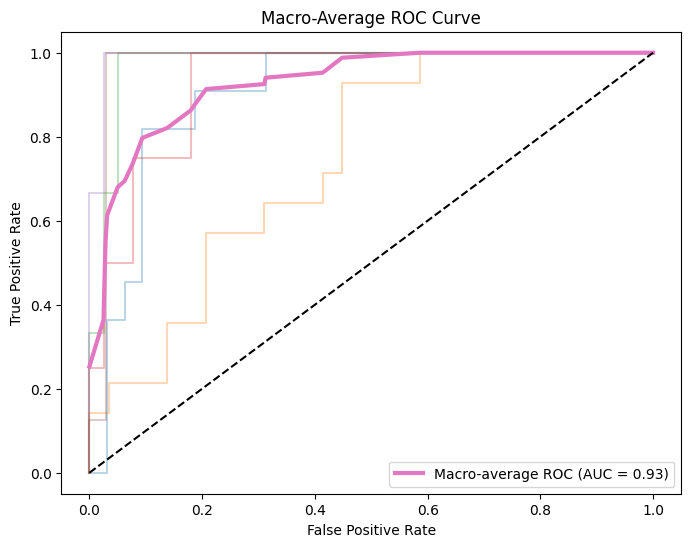

In [ ]:
plt.figure(figsize=(8,6))

# Plot individual curves
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], alpha=0.3)

# Plot macro-average
plt.plot(all_fpr, mean_tpr,
         label=f"Macro-average ROC (AUC = {macro_auc:.2f})",
         linewidth=3)

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Macro-Average ROC Curve")
plt.legend()
plt.show()

#PRECISION–RECALL CURVE

##Import

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

##Compute Precision-Recall

In [ ]:
precision = dict()
recall = dict()
avg_precision = dict()

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(
        y_test_bin[:, i], y_score[:, i]
    )
    avg_precision[i] = average_precision_score(
        y_test_bin[:, i], y_score[:, i]
    )

##Plot Precision-Recall Curve

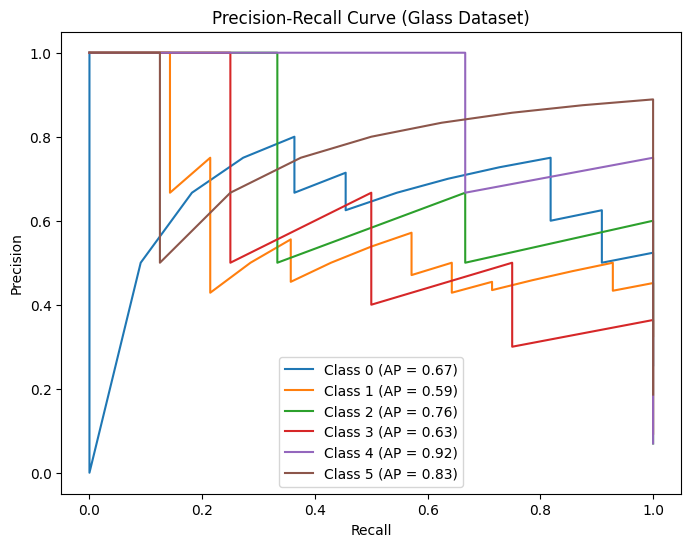

In [ ]:
plt.figure(figsize=(8,6))

for i in range(n_classes):
    plt.plot(recall[i], precision[i],
             label=f"Class {i} (AP = {avg_precision[i]:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Glass Dataset)")
plt.legend()
plt.show()

#MACRO-AVERAGE PRECISION–RECALL

##Macro PR

In [ ]:
# Combine all predictions
precision_all, recall_all, _ = precision_recall_curve(
    y_test_bin.ravel(), y_score.ravel()
)

macro_pr_score = average_precision_score(
    y_test_bin, y_score, average="macro"
)

##Plot Macro PR

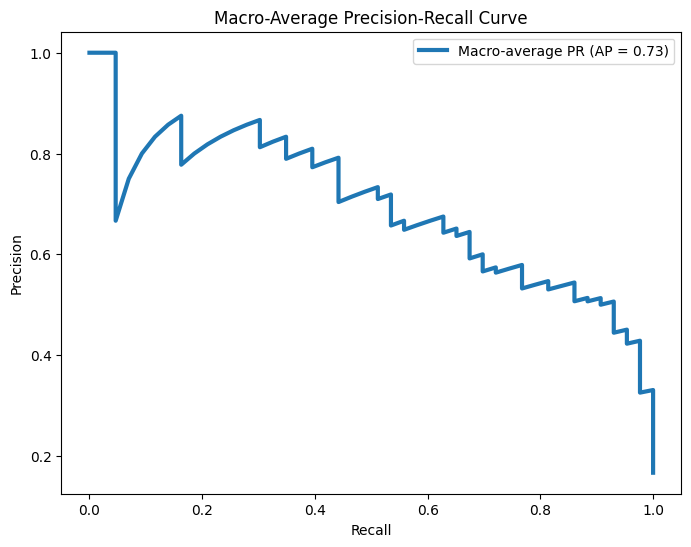

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(recall_all, precision_all,
         label=f"Macro-average PR (AP = {macro_pr_score:.2f})",
         linewidth=3)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Macro-Average Precision-Recall Curve")
plt.legend()
plt.show()